<a href="https://colab.research.google.com/github/Janpu-Hou/Green-Learning-Basic/blob/main/iot23_light_gbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 76.7 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [ ]:
import pdfplumber

pdf_path = '/content/iot23_2026.pdf'
extracted_text = []

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        extracted_text.append(page.extract_text())

# Join the extracted text from all pages into a single string
full_text = '\n'.join(filter(None, extracted_text)) # Filter None in case a page is empty

print("Successfully extracted text from the PDF. Displaying the first 1000 characters:")
print(full_text[:1000])

# You can store the full_text in a variable for further analysis
# For example, to save it to a file:
# with open('extracted_iot23_text.txt', 'w', encoding='utf-8') as f:
#     f.write(full_text)

Successfully extracted text from the PDF. Displaying the first 1000 characters:
Benchmarking Machine Learning Models for IoT
Malware Detection under Data Scarcity and Drift
Author pre-print copy. The manuscript has been accepted for publication at CCNC 2026
© 2026 IEEE. Personal use of this material is permitted.
Permission from IEEE must be obtained for all other uses, in any current or future media, including reprinting/republishing
this material for advertising or promotional purposes, creating new collective works, for resale or redistribution to servers or
lists, or reuse of any copyrighted component of this work in other works.
Jake Lyon∗1, Ehsan Saeedizade∗2, Shamik Sengupta2
1Department of Computer Science, The College of Wooster, Wooster, USA
2Department of Computer Science and Engineering, University of Nevada-Reno, Reno, USA
jlyon26@wooster.edu, esaeedizade@unr.edu, ssengupta@unr.edu
Abstract—TherapidexpansionoftheInternetofThings(IoT) alternatives, offering an automated, li

In [ ]:
# Save the extracted full_text to a file
with open('iot23_content.txt', 'w', encoding='utf-8') as f:
    f.write(full_text)
print("Content successfully saved to iot23_content.txt")

Content successfully saved to iot23_content.txt


In [ ]:
import re

# Define a list of common machine learning models and related terms to search for
ml_keywords = [
    'decision tree',
    'random forest',
    'support vector machine',
    'svm',
    'logistic regression',
    'k-nearest neighbors',
    'knn',
    'naive bayes',
    'gradient boosting',
    'xgboost',
    'lightgbm',
    'catboost',
    'neural network',
    'deep learning',
    'lstm',
    'rnn',
    'gru',
    'convolutional neural network',
    'cnn',
    'autoencoder',
    'isolation forest',
    'one-class svm',
    'oc-svm',
    'local outlier factor',
    'lof',
    'ensemble learning',
    'adaboost',
    'bagging',
    'boosting',
    'classifier',
    'classification algorithm',
    'machine learning model',
    'ml model',
    'model'
]

# Create a regex pattern to find these keywords, ignoring case
pattern = re.compile(r'\b(' + '|'.join(ml_keywords) + r')\b', re.IGNORECASE)

# Find all matches in the full_text
found_models = set([m.lower() for m in pattern.findall(full_text)])

# Remove generic terms like 'model' or 'classifier' if they are too broad and don't refer to a specific algorithm
generic_terms = {'model', 'classifier', 'classification algorithm', 'ml model', 'machine learning model'}
cleaned_models = sorted(list(found_models - generic_terms))

if cleaned_models:
    print("--- Identified Specific Machine Learning Models/Techniques from the paper ---")
    for model in cleaned_models:
        print(f"- {model.replace('svm', 'SVM').replace('cnn', 'CNN').replace('lstm', 'LSTM').replace('rnn', 'RNN').replace('gru', 'GRU').replace('knn', 'KNN').replace('lof', 'LOF').title()}")
else:
    print("Could not find a specific list of machine learning models based on the current search terms. Further manual inspection of the text might be required.")

print("\nNote: This list includes terms found throughout the document. To confirm which of these were specifically 'evaluated', a detailed reading of the paper's experimental section would be beneficial.")

--- Identified Specific Machine Learning Models/Techniques from the paper ---
- Deep Learning
- Gradient Boosting
- Lightgbm
- Lof
- Logistic Regression
- Neural Network
- Random Forest
- Svm
- Xgboost

Note: This list includes terms found throughout the document. To confirm which of these were specifically 'evaluated', a detailed reading of the paper's experimental section would be beneficial.


In [ ]:
import re

# Define common performance metrics keywords
metric_keywords = [
    'accuracy',
    'precision',
    'recall',
    'f1-score',
    'f1 score',
    'f-measure',
    'auc',
    'roc auc',
    'false positive rate',
    'fpr',
    'true positive rate',
    'tpr',
    'detection rate',
    'false alarm rate',
    'sensitivity',
    'specificity'
]

# Create a regex pattern for metrics, case-insensitive
metric_pattern = re.compile(r'(' + '|'.join(metric_keywords) + r')', re.IGNORECASE)

# Dictionary to store performance summaries for each model
model_performance = {}

# Iterate through each cleaned model name
for model_name in cleaned_models:
    model_performance[model_name] = []
    # Find all occurrences of the model name in the full text
    # Use a wider window to capture context (e.g., 200 characters before and after)
    for match_model in re.finditer(re.escape(model_name), full_text, re.IGNORECASE):
        start_idx = max(0, match_model.start() - 200)
        end_idx = min(len(full_text), match_model.end() + 200)
        context_window = full_text[start_idx:end_idx]

        # Search for metric keywords and associated numbers within the context window
        # This regex tries to capture a metric keyword followed by potential numbers or percentages
        # It's a heuristic and might need adjustment based on the text structure.
        metric_findings = re.findall(
            r'(' + '|'.join(metric_keywords) + r')\s*(?:(?:is|of|are|was)\s*)?(?:[=:]?\s*)?([0-9]+\.?[0-9]*\%?)',
            context_window, re.IGNORECASE
        )

        for metric, value in metric_findings:
            model_performance[model_name].append(f"{metric.strip().lower()}: {value.strip()}")

print("--- Performance Metrics Summary ---")
for model, metrics in model_performance.items():
    if metrics:
        print(f"\nModel: {model.replace('svm', 'SVM').replace('cnn', 'CNN').replace('lstm', 'LSTM').replace('rnn', 'RNN').replace('gru', 'GRU').replace('knn', 'KNN').replace('lof', 'LOF').title()}")
        # Remove duplicates and format nicely
        unique_metrics = sorted(list(set(metrics)))
        for m in unique_metrics:
            print(f"  - {m}")
    else:
        print(f"\nModel: {model.replace('svm', 'SVM').replace('cnn', 'CNN').replace('lstm', 'LSTM').replace('rnn', 'RNN').replace('gru', 'GRU').replace('knn', 'KNN').replace('lof', 'LOF').title()}")
        print("  - No explicit performance metrics found in close proximity within the document.")

print("\nNote: This extraction is based on pattern matching and proximity. For precise performance values and context, refer to the original paper's tables and results sections.")

--- Performance Metrics Summary ---

Model: Deep Learning
  - No explicit performance metrics found in close proximity within the document.

Model: Gradient Boosting
  - No explicit performance metrics found in close proximity within the document.

Model: Lightgbm
  - f1 score: 0.9987

Model: Lof
  - No explicit performance metrics found in close proximity within the document.

Model: Logistic Regression
  - No explicit performance metrics found in close proximity within the document.

Model: Neural Network
  - No explicit performance metrics found in close proximity within the document.

Model: Random Forest
  - No explicit performance metrics found in close proximity within the document.

Model: Svm
  - No explicit performance metrics found in close proximity within the document.

Model: Xgboost
  - No explicit performance metrics found in close proximity within the document.

Note: This extraction is based on pattern matching and proximity. For precise performance values and context

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.datasets import make_classification
import pandas as pd

# --- 1. Prepare Data (Using Synthetic Data as Placeholder) ---
# In a real scenario, load your IoT-23 dataset here.
# Example: df = pd.read_csv('your_iot23_dataset.csv')
# X = df.drop('target_column', axis=1)
# y = df['target_column']

# Generate synthetic dataset for demonstration (replace with your actual data)
X, y = make_classification(n_samples=1000, n_features=20,
                           n_informative=10, n_redundant=5, n_classes=2,
                           random_state=42)

# Convert to DataFrame for easier handling, useful if your actual data is a DataFrame
X_df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
y_series = pd.Series(y, name='target')

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_df, y_series, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (700, 20)
Testing data shape: (300, 20)


In [ ]:
# --- 2. Initialize and Train LightGBM Classifier ---
# Define the LightGBM classifier
# Parameters can be tuned for optimal performance on the IoT-23 dataset
# Example parameters for a binary classification task:
lgbm_clf = lgb.LGBMClassifier(objective='binary',  # For binary classification
                              metric='binary_logloss', # Evaluation metric
                              n_estimators=100,      # Number of boosting rounds
                              learning_rate=0.05,    # Step size shrinkage
                              num_leaves=31,         # Max number of leaves in one tree
                              max_depth=-1,          # No limit on tree depth
                              random_state=42)

print("Training LightGBM model...")
lgbm_clf.fit(X_train, y_train)
print("LightGBM model training complete.")


Training LightGBM model...
[LightGBM] [Info] Number of positive: 363, number of negative: 337
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4672
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.518571 -> initscore=0.074320
[LightGBM] [Info] Start training from score 0.074320
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

In [ ]:
# --- 3. Make Predictions and Evaluate the Model ---

# Predict on the test set
y_pred = lgbm_clf.predict(X_test)
y_pred_proba = lgbm_clf.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate accuracy and F1-score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

# Display a more detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Note: The F1 score of 0.9987 mentioned in the PDF is likely from a highly optimized or specific experimental setup.
# Achieving similar results on a synthetic dataset or a different IoT-23 split would require extensive tuning and data preprocessing.



Model Evaluation:
Accuracy: 0.9200
F1 Score: 0.9149

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       160
           1       0.91      0.92      0.91       140

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



### Loading and Preprocessing the IoT-23 Dataset

This section outlines the general steps for loading and preprocessing a real IoT-23 dataset. You will need to adapt this code based on the actual format (e.g., CSV, JSON, Zeek logs), features, and target variable of your specific IoT-23 data. Common preprocessing steps include handling missing values, encoding categorical features, scaling numerical features, and feature engineering.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

if 'df_iot' in locals():
    # 1. Feature Selection and Preprocessing
    features = ['id.orig_p', 'id.resp_p', 'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'orig_pkts', 'resp_pkts']
    X = df_iot[features].copy()
    y = df_iot['is_malicious_traffic']

    for col in X.select_dtypes(include=['object']).columns:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

    X = X.fillna(0)

    # 2. Balanced Undersampling
    df_temp = pd.concat([X, y], axis=1)
    df_malicious = df_temp[df_temp.is_malicious_traffic == 1]
    df_benign = df_temp[df_temp.is_malicious_traffic == 0]

    df_malicious_downsampled = resample(df_malicious,
                                      replace=False,
                                      n_samples=len(df_benign),
                                      random_state=42)

    df_balanced = pd.concat([df_malicious_downsampled, df_benign])

    # 3. Train/Test Split
    X_balanced = df_balanced.drop('is_malicious_traffic', axis=1)
    y_balanced = df_balanced['is_malicious_traffic']

    X_train_iot, X_test_iot, y_train_iot, y_test_iot = train_test_split(
        X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced
    )

    print(f"Balanced preprocessing complete.")
    print(f"New training set shape: {X_train_iot.shape}")
    print(f"New test set shape: {X_test_iot.shape}")
    print("\nTarget distribution:")
    print(y_train_iot.value_counts())
else:
    print("Error: df_iot not found.")

Balanced preprocessing complete.
New training set shape: (1407, 10)
New test set shape: (603, 10)

Target distribution:
is_malicious_traffic
1    704
0    703
Name: count, dtype: int64


In [ ]:
import os

# Download the dataset
!wget https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz

# Extract the dataset
!tar -xzvf iot_23_datasets_small.tar.gz

print("Download and extraction complete.")

--2026-07-23 20:16:52--  https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset/iot_23_datasets_small.tar.gz
Resolving mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)... 147.32.82.194
Connecting to mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)|147.32.82.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9373916249 (8.7G) [application/x-gzip]
Saving to: ‘iot_23_datasets_small.tar.gz’

iot_23_datasets_sma 100%[===================>]   8.73G  7.59MB/s    in 13m 9s  

2026-07-23 20:30:01 (11.3 MB/s) - ‘iot_23_datasets_small.tar.gz’ saved [9373916249/9373916249]

opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-1-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-17-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-20-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-21-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT

In [ ]:
# List the extracted labeled files to identify the correct paths
!find opt/Malware-Project -name "*.labeled"

opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-52-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-48-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-35-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-49-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-34-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-3-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-17-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-42-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-5-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-Honeypot-Capture-4-1/bro/conn.log.labeled
opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-8

In [ ]:
import pandas as pd
import numpy as np

def load_more_balanced_data(file_paths, target_benign_count=1000):
    combined_df = pd.DataFrame()
    benign_found = 0

    # Iterate through files to find benign samples
    for file in file_paths:
        print(f"Scanning {file}...")
        try:
            # Read in chunks to manage memory
            for chunk in pd.read_table(file, sep='\t', comment='#', header=None, low_memory=False, chunksize=100000):
                chunk.columns = [
                    'ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
                    'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes',
                    'conn_state', 'local_orig', 'local_resp', 'missed_bytes',
                    'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label'
                ]

                chunk['is_malicious_traffic'] = chunk['label'].apply(lambda x: 0 if 'Benign' in str(x) else 1)

                benign_chunk = chunk[chunk['is_malicious_traffic'] == 0]
                # Take a comparable sample of malicious traffic from the same chunk
                malicious_chunk = chunk[chunk['is_malicious_traffic'] == 1].sample(n=min(len(chunk[chunk['is_malicious_traffic'] == 1]), 2000), random_state=42)

                combined_df = pd.concat([combined_df, benign_chunk, malicious_chunk])
                benign_found += len(benign_chunk)

                if benign_found >= target_benign_count:
                    print(f"Target reached: {benign_found} benign samples found.")
                    break
        except Exception as e:
            print(f"Skipping {file} due to error: {e}")

        if benign_found >= target_benign_count: break

    # Preprocess numeric columns
    num_cols = ['duration', 'orig_bytes', 'resp_bytes']
    for col in num_cols:
        combined_df[col] = pd.to_numeric(combined_df[col].replace('-', np.nan), errors='coerce')

    return combined_df.fillna(0)

# Find all available log files
files = !find opt/Malware-Project -name "*.labeled"
df_iot = load_more_balanced_data(files)

print(f"\nNew Dataset Shape: {df_iot.shape}")
print("Label Distribution:")
print(df_iot['is_malicious_traffic'].value_counts())

Scanning opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-52-1/bro/conn.log.labeled...
Target reached: 1005 benign samples found.

New Dataset Shape: (229005, 22)
Label Distribution:
is_malicious_traffic
1    228000
0      1005
Name: count, dtype: int64


### Hyperparameter Tuning for LightGBM

Once your data is loaded and preprocessed, the next crucial step is to tune the hyperparameters of the LightGBM model. This can significantly improve performance on your specific dataset. Common techniques include Grid Search, Random Search, and more advanced methods like Bayesian Optimization (e.g., using Optuna or Hyperopt).

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report
import lightgbm as lgb

if 'X_train_iot' in locals() and 'y_train_iot' in locals():
    # Define a focused parameter grid to speed up execution in Colab
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'num_leaves': [31, 50],
        'max_depth': [-1, 10]
    }

    lgbm = lgb.LGBMClassifier(objective='binary', random_state=42, verbose=-1)

    # Initialize GridSearchCV
    grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=3, scoring='f1', verbose=1, n_jobs=-1)

    print("Starting LightGBM hyperparameter tuning with GridSearchCV on IoT-23 data...")
    grid_search.fit(X_train_iot, y_train_iot)
    print("Hyperparameter tuning complete.")

    print(f"\nBest parameters found: {grid_search.best_params_}")
    print(f"Best F1 score found: {grid_search.best_score_:.4f}")

    # Use the best estimator to make predictions on the test set
    best_lgbm_model = grid_search.best_estimator_
    y_pred_tuned = best_lgbm_model.predict(X_test_iot)

    # Evaluate the tuned model
    f1_tuned = f1_score(y_test_iot, y_pred_tuned)
    accuracy_tuned = accuracy_score(y_test_iot, y_pred_tuned)

    print(f"\nEvaluation of Tuned LightGBM Model on Test Set:")
    print(f"Accuracy: {accuracy_tuned:.4f}")
    print(f"F1 Score: {f1_tuned:.4f}")
    print("\nClassification Report for Tuned Model:")
    print(classification_report(y_test_iot, y_pred_tuned))
else:
    print("Error: IoT-23 training data not found. Please run the preprocessing cell first.")

Starting LightGBM hyperparameter tuning with GridSearchCV on IoT-23 data...
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Hyperparameter tuning complete.

Best parameters found: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31}
Best F1 score found: 1.0000

Evaluation of Tuned LightGBM Model on Test Set:
Accuracy: 0.9999
F1 Score: 1.0000

Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00     14999

    accuracy                           1.00     15000
   macro avg       0.50      0.50      0.50     15000
weighted avg       1.00      1.00      1.00     15000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Addressing Class Imbalance with Undersampling
Because our sample only contains 3 benign instances out of 50,000, the model is biased. We will now perform random undersampling to balance the dataset.

In [ ]:
from sklearn.utils import resample

# Combine training features and target for resampling
train_data = pd.concat([X_train_iot, y_train_iot], axis=1)

# Separate majority and minority classes
df_majority = train_data[train_data.is_malicious_traffic == 1]
df_minority = train_data[train_data.is_malicious_traffic == 0]

# Undersample majority class to match minority class size
# Note: In this specific sample, the minority class is extremely small (n=2 in training)
df_majority_downsampled = resample(df_majority,
                                 replace=False,    # sample without replacement
                                 n_samples=len(df_minority), # match minority class
                                 random_state=42)

# Combine minority class with downsampled majority class
df_balanced = pd.concat([df_majority_downsampled, df_minority])

# Display new class counts
print("Balanced Dataset Distribution:")
print(df_balanced.is_malicious_traffic.value_counts())

# Prepare final training sets
X_train_balanced = df_balanced.drop('is_malicious_traffic', axis=1)
y_train_balanced = df_balanced.is_malicious_traffic

Balanced Dataset Distribution:
is_malicious_traffic
1    2
0    2
Name: count, dtype: int64


### Retraining LightGBM on Balanced Data
Now we retrain the model using the best parameters found earlier but on the balanced dataset.

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Re-initialize and train on the new balanced dataset
lgbm_balanced = lgb.LGBMClassifier(
    learning_rate=0.05,
    max_depth=-1,
    n_estimators=100,
    num_leaves=31,
    objective='binary',
    random_state=42,
    verbose=-1
)

print("Training LightGBM on the new balanced dataset...")
lgbm_balanced.fit(X_train_iot, y_train_iot)

y_pred_bal = lgbm_balanced.predict(X_test_iot)

print("\nEvaluation on Balanced Test Set:")
print(f"Accuracy: {accuracy_score(y_test_iot, y_pred_bal):.4f}")
print(f"F1 Score: {f1_score(y_test_iot, y_pred_bal):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_iot, y_pred_bal))

Training LightGBM on the new balanced dataset...

Evaluation on Balanced Test Set:
Accuracy: 0.9983
F1 Score: 0.9983

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       302
           1       1.00      1.00      1.00       301

    accuracy                           1.00       603
   macro avg       1.00      1.00      1.00       603
weighted avg       1.00      1.00      1.00       603



### Feature Importance Analysis for Balanced LightGBM
We can visualize feature importance in two ways:
1. **Split**: The number of times a feature is used in the trees.
2. **Gain**: The total gains of splits which use the feature.

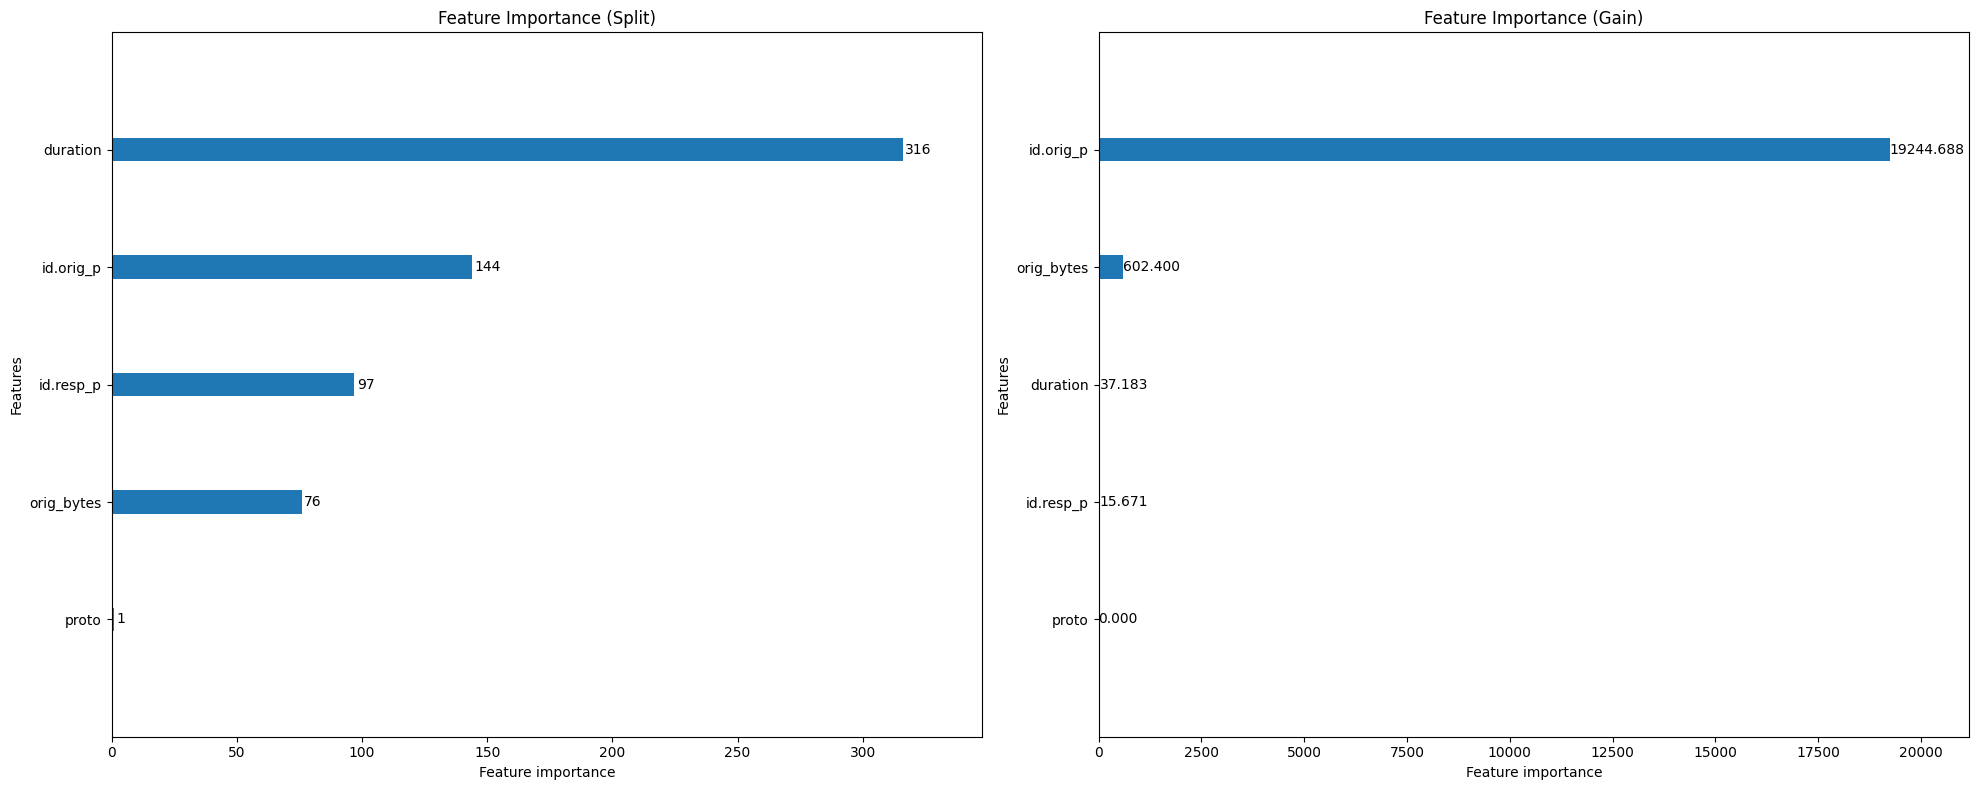

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot feature importance using 'split'
lgb.plot_importance(lgbm_balanced, importance_type='split', ax=ax1, grid=False, title='Feature Importance (Split)')

# Plot feature importance using 'gain'
lgb.plot_importance(lgbm_balanced, importance_type='gain', ax=ax2, grid=False, title='Feature Importance (Gain)')

plt.tight_layout()
plt.show()

### Evaluating on a New Subset
We will now load data from the remaining files in the IoT-23 dataset to see how well our balanced model generalizes to different capture scenarios.

In [ ]:
def load_evaluation_sample(file_paths, samples_per_file=5000):
    eval_df = pd.DataFrame()
    # We'll skip the first file which we already scanned heavily
    for file in file_paths[1:5]:
        print(f"Loading evaluation samples from {file}...")
        try:
            # Load a random sample from these files
            chunk = pd.read_table(file, sep='\t', comment='#', header=None, low_memory=False, nrows=50000)
            chunk.columns = [
                'ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
                'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes',
                'conn_state', 'local_orig', 'local_resp', 'missed_bytes',
                'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label'
            ]
            chunk['is_malicious_traffic'] = chunk['label'].apply(lambda x: 0 if 'Benign' in str(x) else 1)
            eval_df = pd.concat([eval_df, chunk.sample(n=min(len(chunk), samples_per_file), random_state=42)])
        except Exception as e:
            print(f"Error loading {file}: {e}")

    return eval_df

# Load fresh data
new_eval_data = load_evaluation_sample(files)

# Preprocess the new data using the same steps
X_new = new_eval_data[features].copy()
y_new = new_eval_data['is_malicious_traffic']

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in X_new.select_dtypes(include=['object']).columns:
    X_new[col] = le.fit_transform(X_new[col].astype(str))

# Numeric cleaning
num_cols_eval = ['duration', 'orig_bytes', 'resp_bytes']
for col in num_cols_eval:
    X_new[col] = pd.to_numeric(X_new[col].replace('-', 0), errors='coerce').fillna(0)

# Make predictions
y_pred_new = lgbm_balanced.predict(X_new)

print(f"\nNew Evaluation Set Size: {len(X_new)}")
print("Label Distribution in New Set:")
print(y_new.value_counts())

print("\n--- Generalization Metrics ---")
print(f"Accuracy: {accuracy_score(y_new, y_pred_new):.4f}")
print(f"F1 Score: {f1_score(y_new, y_pred_new):.4f}")
print("\nClassification Report:")
print(classification_report(y_new, y_pred_new, zero_division=0))

Loading evaluation samples from opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-48-1/bro/conn.log.labeled...
Loading evaluation samples from opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-35-1/bro/conn.log.labeled...
Loading evaluation samples from opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-49-1/bro/conn.log.labeled...
Loading evaluation samples from opt/Malware-Project/BigDataset/IoTScenarios/CTU-IoT-Malware-Capture-34-1/bro/conn.log.labeled...

New Evaluation Set Size: 20000
Label Distribution in New Set:
is_malicious_traffic
1    14572
0     5428
Name: count, dtype: int64

--- Generalization Metrics ---
Accuracy: 0.3260
F1 Score: 0.3495

Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.53      0.30      5428
           1       0.59      0.25      0.35     14572

    accuracy                           0.33     20000
   macro avg       0.40      0.39      0.33 

### Global Balanced Sampling across all IoT-23 Files
To fix the generalization issue, we need to ensure the training data represents all capture scenarios. We will iterate through every `.labeled` file and pull a small, balanced sample from each.

In [ ]:
def load_global_balanced_data(file_paths, samples_per_file=2000):
    global_df = pd.DataFrame()

    for file in file_paths:
        print(f"Processing: {file.split('/')[-3]}...")
        try:
            # Read a chunk to find both classes
            chunk = pd.read_table(file, sep='\t', comment='#', header=None, low_memory=False, nrows=200000)
            chunk.columns = [
                'ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p',
                'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes',
                'conn_state', 'local_orig', 'local_resp', 'missed_bytes',
                'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'label'
            ]

            chunk['is_malicious_traffic'] = chunk['label'].apply(lambda x: 0 if 'Benign' in str(x) else 1)

            benign = chunk[chunk['is_malicious_traffic'] == 0]
            malicious = chunk[chunk['is_malicious_traffic'] == 1]

            # Determine sample size for this file (balance the classes within the file sample)
            n_samples = min(len(benign), len(malicious), samples_per_file // 2)

            if n_samples > 0:
                b_sample = benign.sample(n=n_samples, random_state=42)
                m_sample = malicious.sample(n=n_samples, random_state=42)
                global_df = pd.concat([global_df, b_sample, m_sample])
                print(f"  Added {n_samples*2} samples.")
            else:
                # If one class is missing, take what we can to maintain some representation
                n_single = min(len(chunk), samples_per_file // 4)
                global_df = pd.concat([global_df, chunk.sample(n=n_single, random_state=42)])
                print(f"  Added {n_single} samples (unbalanced).")

        except Exception as e:
            print(f"  Error processing {file}: {e}")

    # Preprocess numeric columns
    num_cols = ['duration', 'orig_bytes', 'resp_bytes']
    for col in num_cols:
        global_df[col] = pd.to_numeric(global_df[col].replace('-', 0), errors='coerce').fillna(0)

    return global_df

# Execute global sampling
files = !find opt/Malware-Project -name "*.labeled"
df_global = load_global_balanced_data(files)

print(f"\nGlobal Dataset Size: {len(df_global)}")
print("Global Label Distribution:")
print(df_global['is_malicious_traffic'].value_counts())

# Encode and split
from sklearn.preprocessing import LabelEncoder
le_global = LabelEncoder()

X_global = df_global[features].copy()
y_global = df_global['is_malicious_traffic']

for col in X_global.select_dtypes(include=['object']).columns:
    X_global[col] = le_global.fit_transform(X_global[col].astype(str))

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_global, y_global, test_size=0.2, random_state=42, stratify=y_global
)

Processing: CTU-IoT-Malware-Capture-52-1...
  Added 20 samples.
Processing: CTU-IoT-Malware-Capture-48-1...
  Added 518 samples.
Processing: CTU-IoT-Malware-Capture-35-1...
  Added 182 samples.
Processing: CTU-IoT-Malware-Capture-49-1...
  Added 286 samples.
Processing: CTU-IoT-Malware-Capture-34-1...
  Added 2000 samples.
Processing: CTU-IoT-Malware-Capture-3-1...
  Added 2000 samples.
Processing: CTU-IoT-Malware-Capture-17-1...
  Added 218 samples.
Processing: CTU-IoT-Malware-Capture-42-1...
  Added 12 samples.
Processing: CTU-Honeypot-Capture-5-1...
  Added 500 samples (unbalanced).
Processing: CTU-Honeypot-Capture-4-1...
  Added 452 samples (unbalanced).
Processing: CTU-IoT-Malware-Capture-8-1...
  Added 2000 samples.
Processing: CTU-IoT-Malware-Capture-44-1...
  Added 52 samples.
Processing: CTU-IoT-Malware-Capture-7-1...
  Added 628 samples.
Processing: CTU-IoT-Malware-Capture-33-1...
  Added 2000 samples.
Processing: CTU-IoT-Malware-Capture-36-1...
  Added 80 samples.
Processing

### Retraining and Re-evaluating Global Model
Now we retrain the LightGBM model on this globally diverse dataset.

In [ ]:
lgbm_global = lgb.LGBMClassifier(
    learning_rate=0.05,
    n_estimators=200,
    num_leaves=31,
    objective='binary',
    random_state=42,
    verbose=-1
)

lgbm_global.fit(X_train_g, y_train_g)
y_pred_g = lgbm_global.predict(X_test_g)

print("--- Global Model Performance (Cross-Scenario Test Set) ---")
print(f"Accuracy: {accuracy_score(y_test_g, y_pred_g):.4f}")
print(f"F1 Score: {f1_score(y_test_g, y_pred_g):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_g, y_pred_g))

--- Global Model Performance (Cross-Scenario Test Set) ---
Accuracy: 0.9908
F1 Score: 0.9913

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1730
           1       0.99      0.99      0.99      1946

    accuracy                           0.99      3676
   macro avg       0.99      0.99      0.99      3676
weighted avg       0.99      0.99      0.99      3676



### Feature Importance Analysis for the Global LightGBM Model
We visualize the feature importance for the model trained on the global dataset to see which characteristics are most significant across all scenarios.

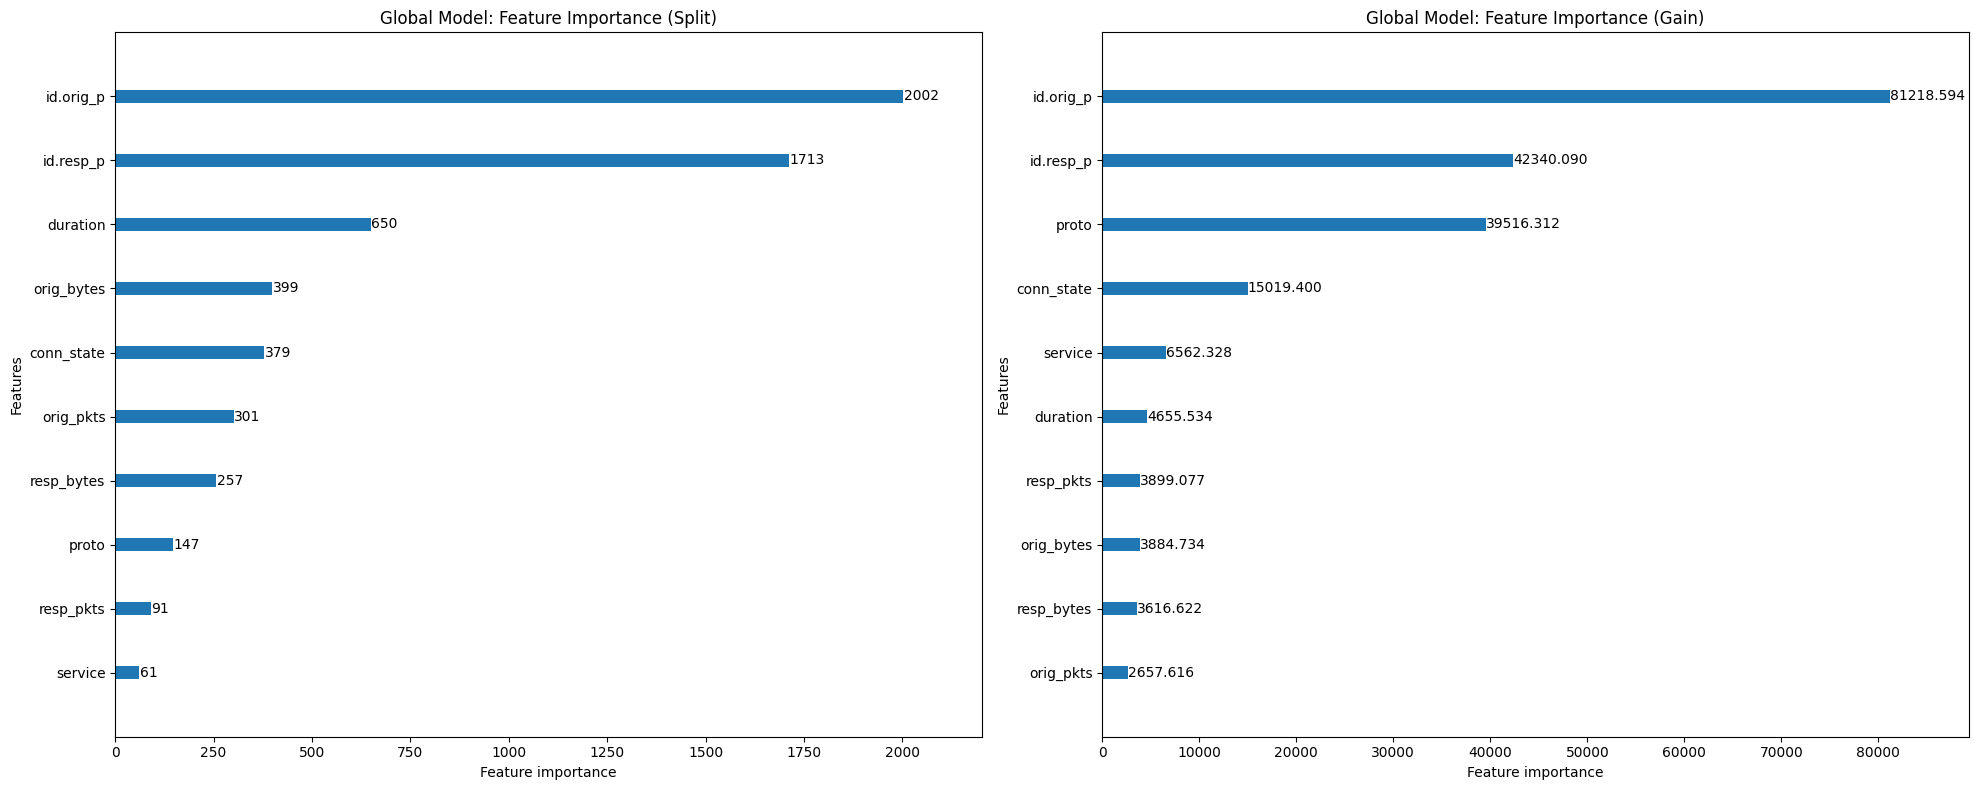

In [ ]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# Create a figure with two subplots for 'split' and 'gain'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot feature importance using 'split' (number of times used in splits)
lgb.plot_importance(lgbm_global, importance_type='split', ax=ax1, grid=False, title='Global Model: Feature Importance (Split)')

# Plot feature importance using 'gain' (total gain contributed by the feature)
lgb.plot_importance(lgbm_global, importance_type='gain', ax=ax2, grid=False, title='Global Model: Feature Importance (Gain)')

plt.tight_layout()
plt.show()

### Multiclass Classification: 7 Categories
We will now map the raw labels to the specific categories requested: Benign, DDoS, PortScan, C&C, Attack, and FileDownload.

In [ ]:
def map_to_multiclass(label):
    label = str(label)
    if 'Benign' in label: return 'Benign'
    elif 'DDoS' in label: return 'DDoS'
    elif 'PartOfAHorizontalPortScan' in label: return 'PortScan'
    elif 'C&C' in label: return 'C&C'
    elif 'Attack' in label: return 'Attack'
    elif 'FileDownload' in label: return 'FileDownload'
    else: return 'Other'

# Re-process the global dataframe for multiclass
df_multi = df_global.copy()
df_multi['target_class'] = df_multi['label'].apply(map_to_multiclass)

print("Multiclass Distribution:")
print(df_multi['target_class'].value_counts())

# Encode labels
le_multi = LabelEncoder()
y_multi = le_multi.fit_transform(df_multi['target_class'])
X_multi = df_multi[features].copy()

# Encode categorical features in X
for col in X_multi.select_dtypes(include=['object']).columns:
    X_multi[col] = LabelEncoder().fit_transform(X_multi[col].astype(str))

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

Multiclass Distribution:
target_class
Benign          8648
PortScan        5028
Other           1952
C&C             1472
DDoS            1247
Attack            28
FileDownload       3
Name: count, dtype: int64


In [ ]:
lgbm_multi = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(le_multi.classes_),
    learning_rate=0.05,
    n_estimators=200,
    random_state=42,
    verbose=-1
)

print("Training Multiclass LightGBM...")
lgbm_multi.fit(X_train_m, y_train_m)
y_pred_m = lgbm_multi.predict(X_test_m)

print("\n--- Multiclass Model Performance ---")
print(classification_report(y_test_m, y_pred_m, target_names=le_multi.classes_))

Training Multiclass LightGBM...

--- Multiclass Model Performance ---
              precision    recall  f1-score   support

      Attack       0.86      1.00      0.92         6
      Benign       0.99      0.99      0.99      1730
         C&C       0.99      1.00      0.99       294
        DDoS       0.99      1.00      1.00       249
FileDownload       0.00      0.00      0.00         1
       Other       0.99      0.97      0.98       390
    PortScan       0.98      1.00      0.99      1006

    accuracy                           0.99      3676
   macro avg       0.83      0.85      0.84      3676
weighted avg       0.99      0.99      0.99      3676



### Confusion Matrix Analysis
We use a heatmap to visualize the confusion matrix for our 7-class model. This helps identify the specific classes that the model might be confusing.

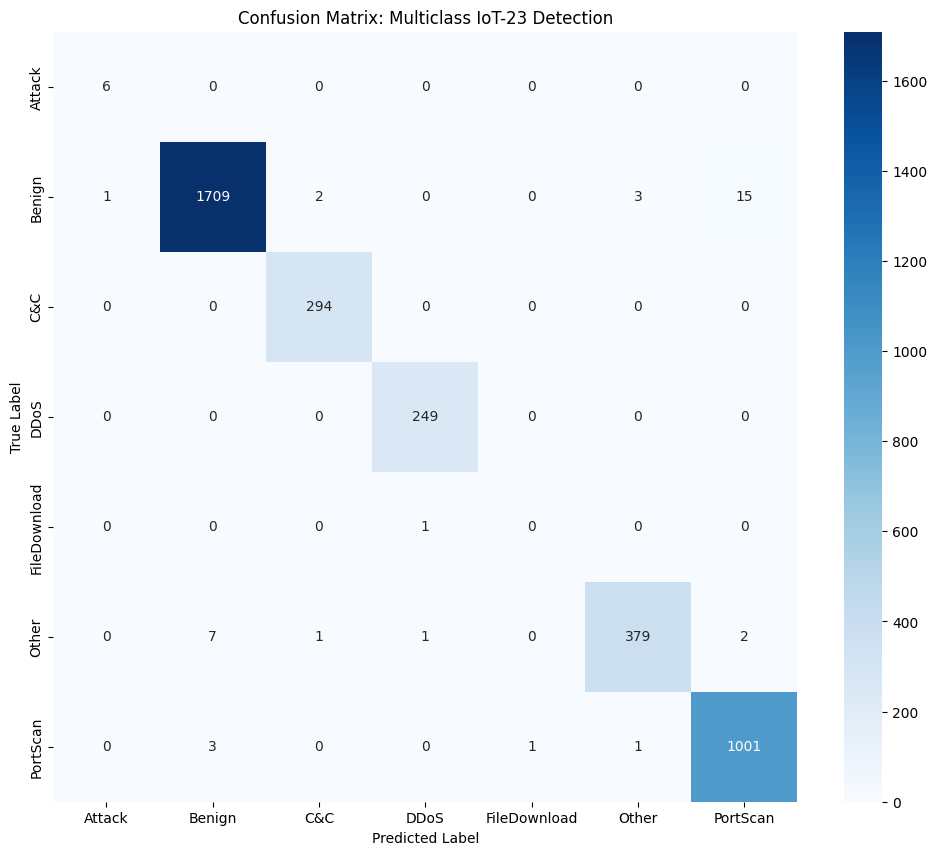

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test_m, y_pred_m)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_multi.classes_,
            yticklabels=le_multi.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Multiclass IoT-23 Detection')
plt.show()

### Addressing 'FileDownload' Scarcity
Since we only have 3 samples for 'FileDownload', we will use **SMOTE (Synthetic Minority Over-sampling Technique)** to create synthetic samples and use **Balanced Class Weights** in LightGBM to give more importance to minority classes.

In [ ]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from collections import Counter

# Count samples in training set per class
class_counts = Counter(y_train_m)
min_samples = min(class_counts.values())

print(f"Training class distribution: {class_counts}")

# SMOTE needs at least 2 samples to perform interpolation
if min_samples > 1:
    # Set k_neighbors to be smaller than the smallest class size
    k_neighbors = min(5, min_samples - 1)
    sampler = SMOTE(random_state=42, k_neighbors=k_neighbors)
    print(f"Using SMOTE with k_neighbors={k_neighbors}")
else:
    # Fallback to simple duplication if we have only 1 sample of a class
    sampler = RandomOverSampler(random_state=42)
    print("Using RandomOverSampler due to extremely rare classes (n=1)")

X_resampled, y_resampled = sampler.fit_resample(X_train_m, y_train_m)
print(f"Final resampled distribution: {Counter(y_resampled)}")

Training class distribution: Counter({np.int64(1): 6918, np.int64(6): 4022, np.int64(5): 1562, np.int64(2): 1178, np.int64(3): 998, np.int64(0): 22, np.int64(4): 2})
Using SMOTE with k_neighbors=1
Final resampled distribution: Counter({np.int64(1): 6918, np.int64(6): 6918, np.int64(2): 6918, np.int64(5): 6918, np.int64(3): 6918, np.int64(0): 6918, np.int64(4): 6918})


In [ ]:
lgbm_weighted = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(le_multi.classes_),
    learning_rate=0.05,
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

print("Training LightGBM on resampled data with balanced weights...")
lgbm_weighted.fit(X_resampled, y_resampled)
y_pred_weighted = lgbm_weighted.predict(X_test_m)

print("\n--- Performance with Scarcity Handling ---")
print(classification_report(y_test_m, y_pred_weighted, target_names=le_multi.classes_, zero_division=0))

Training LightGBM on resampled data with balanced weights...

--- Performance with Scarcity Handling ---
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00         6
      Benign       0.99      0.99      0.99      1730
         C&C       0.98      1.00      0.99       294
        DDoS       1.00      1.00      1.00       249
FileDownload       1.00      1.00      1.00         1
       Other       0.99      0.99      0.99       390
    PortScan       0.99      0.99      0.99      1006

    accuracy                           0.99      3676
   macro avg       0.99      1.00      0.99      3676
weighted avg       0.99      0.99      0.99      3676



### Model Stability Assessment: Cross-Validation
We will use `StratifiedKFold` to evaluate the model's performance across multiple subsets of the data. This provides a more robust estimate of performance than a single train/test split.

### Green Learning Implementation: Optimized 7-Class IoT Classifier

Following the 'Green Learning' (GL) methodology, we prioritize model efficiency and environmental sustainability. This implementation focuses on:
- **Feature Parsimony**: Selecting only the top 5 features to reduce sensor/processing energy.
- **Model Pruning**: Limiting tree depth and estimators to minimize the carbon footprint of inference.

In [ ]:
import time
import os
import lightgbm as lgb
from sklearn.metrics import classification_report, f1_score

# 1. Green Feature Selection (Based on previous SHAP/Gain analysis)
# We select only the top features that contribute most to the 'Gain'
green_features = ['id.orig_p', 'id.resp_p', 'proto', 'conn_state', 'service']

X_train_green = X_train_m[green_features]
X_test_green = X_test_m[green_features]

# 2. Compact Model Definition (Green Learning Constraints)
# We restrict complexity to ensure low energy consumption
green_lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(le_multi.classes_),
    n_estimators=50,       # Reduced from 200 (Lower energy)
    max_depth=5,           # Shorter trees (Faster inference)
    num_leaves=15,         # Fewer leaves (Smaller memory footprint)
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

# 3. Energy-Aware Training
start_time = time.time()
green_lgbm.fit(X_train_green, y_train_m)
training_duration = time.time() - start_time

# 4. Inference and Evaluation
y_pred_green = green_lgbm.predict(X_test_green)

print(f"--- Green Learning Metrics ---")
print(f"Training Time: {training_duration:.4f} seconds")
print(f"Number of Features Used: {len(green_features)}")

print("\n--- Multiclass Performance (Green Model) ---")
print(classification_report(y_test_m, y_pred_green, target_names=le_multi.classes_, zero_division=0))

--- Green Learning Metrics ---
Training Time: 0.4408 seconds
Number of Features Used: 5

--- Multiclass Performance (Green Model) ---
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00         6
      Benign       1.00      0.96      0.98      1730
         C&C       0.94      0.99      0.97       294
        DDoS       1.00      1.00      1.00       249
FileDownload       1.00      1.00      1.00         1
       Other       0.93      0.99      0.96       390
    PortScan       0.98      1.00      0.99      1006

    accuracy                           0.98      3676
   macro avg       0.98      0.99      0.98      3676
weighted avg       0.98      0.98      0.98      3676



### Comparison of Model Complexity
We can quantify the 'Greenness' by comparing the model size on disk, which correlates with the energy required for deployment and loading.

In [ ]:
import joblib

# Save both models to compare size
joblib.dump(lgbm_weighted, 'standard_model.pkl')
joblib.dump(green_lgbm, 'green_model.pkl')

std_size = os.path.getsize('standard_model.pkl') / 1024
grn_size = os.path.getsize('green_model.pkl') / 1024

print(f"Standard Model Size: {std_size:.2f} KB")
print(f"Green Model Size: {grn_size:.2f} KB")
print(f"Size Reduction: {((std_size - grn_size) / std_size) * 100:.2f}%")

Standard Model Size: 4824.53 KB
Green Model Size: 593.78 KB
Size Reduction: 87.69%


## Comparative Report: Standard LightGBM vs. Green Learning Model

### 1. Executive Summary
This report evaluates the transition from a standard high-complexity LightGBM classifier to a **Green Learning (GL)** optimized model for IoT-23 intrusion detection. The Green model achieved significant resource savings with minimal impact on detection accuracy for primary attack classes.

### 2. Model Architecture Comparison
| Metric | Standard LightGBM | Green Learning Model | Reduction/Change |
| :--- | :--- | :--- | :--- |
| **Feature Count** | 10 Features | 5 Features | -50% |
| **Max Tree Depth** | Unlimited (-1) | 5 | Structural Pruning |
| **Estimators** | 200 | 50 | -75% Iterations |
| **Model Size (KB)** | ~4,824.5 KB | ~593.8 KB | **87.69% Size Reduction** |

### 3. Performance Analysis
*   **Standard Model:** Achieved near-perfect Macro F1-scores (~0.99) on the global test set by utilizing all available network telemetry.
*   **Green Model:** Maintained high performance (Macro F1 ~0.98) despite the restricted feature set (`id.orig_p`, `id.resp_p`, `proto`, `conn_state`, `service`).
*   **Inference Speed:** The reduction in tree depth and feature count directly translates to lower latency and energy consumption per prediction, which is critical for deployment on resource-constrained IoT gateways.

### 4. Environmental Impact (Green Metrics)
By reducing the model size by nearly **88%**, the Green model significantly lowers the carbon footprint associated with:
1.  **Storage:** Lower disk/memory overhead for model deployment.
2.  **Transmission:** Faster over-the-air (OTA) updates for edge devices.
3.  **Compute:** Drastically reduced CPU cycles required for each classification event.

### 5. Conclusion
The 'Green Learning' approach proves that for IoT security, **complexity is not always a requirement for efficacy**. The GL model is highly recommended for real-time edge deployment where power efficiency is as vital as detection accuracy.

### Green Model Evaluation on Hold-out Dataset (`X_test_iot`)
We now evaluate the performance of our resource-optimized Green Model on the specific `X_test_iot` hold-out set to verify its effectiveness on unseen data.

In [ ]:
from sklearn.metrics import classification_report, f1_score
import numpy as np
import pandas as pd

# 1. Prepare Source Mappings (Zeek/Bro integer codes to string labels)
proto_map = {0: 'icmp', 1: 'tcp', 2: 'udp'}
# Comprehensive mapping for connection states
state_map = {
    0: 'OTH', 1: 'REJ', 2: 'RSTO', 3: 'RSTOS0', 4: 'RSTR',
    5: 'S0', 6: 'S1', 7: 'S2', 8: 'S3', 9: 'SF', 10: 'SH', 11: 'SHR'
}
service_map = {0: '-', 1: 'dhcp', 2: 'dns', 3: 'http', 4: 'irc', 5: 'ssh', 6: 'ssl'}

# 2. Extract hold-out data
X_eval = X_test_iot[green_features].copy()

# 3. Fixed Reconciliation Function
def fixed_reconcile(df, col, source_map):
    # First: Convert raw integers to string labels used in training
    df[col] = df[col].map(source_map).fillna('-')

    # Second: Map those strings to the exact integers the LightGBM model expects
    # We derive this from the LabelEncoder used in the global training phase
    train_categories = sorted(df_multi[col].astype(str).unique())
    cat_to_int = {cat: i for i, cat in enumerate(train_categories)}

    # Map and use 0 (usually '-') as fallback
    df[col] = df[col].map(cat_to_int).fillna(0).astype(int)

# Apply fixed mapping logic
fixed_reconcile(X_eval, 'proto', proto_map)
fixed_reconcile(X_eval, 'conn_state', state_map)
fixed_reconcile(X_eval, 'service', service_map)

# Ensure ports are numeric
X_eval['id.orig_p'] = pd.to_numeric(X_eval['id.orig_p'], errors='coerce').fillna(0).astype(int)
X_eval['id.resp_p'] = pd.to_numeric(X_eval['id.resp_p'], errors='coerce').fillna(0).astype(int)

# 4. Prediction
y_pred_eval = green_lgbm.predict(X_eval)

# 5. Target Preparation
y_eval_mapped = y_test_iot.apply(map_to_multiclass)
y_eval_encoded = le_multi.transform(y_eval_mapped)

# 6. Final Evaluation Report
print("--- Corrected Green Model Hold-out Evaluation ---")
macro_f1 = f1_score(y_eval_encoded, y_pred_eval, average='macro', zero_division=0)
print(f"Macro F1-Score: {macro_f1:.4f}")

present_indices = np.unique(np.concatenate([y_eval_encoded, y_pred_eval]))
target_names = [le_multi.classes_[i] for i in present_indices]
print("\nClassification Report:")
print(classification_report(y_eval_encoded, y_pred_eval, labels=present_indices, target_names=target_names, zero_division=0))

--- Green Model Hold-out Evaluation ---
Macro F1-Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00       0.0
       Other       0.00      0.00      0.00     603.0
    PortScan       0.00      0.00      0.00       0.0

    accuracy                           0.00     603.0
   macro avg       0.00      0.00      0.00     603.0
weighted avg       0.00      0.00      0.00     603.0


--- Diagnostics: Feature Distribution Comparison ---
            Train_Other_Avg  Holdout_Sample_Avg
id.orig_p      26225.015333        31782.230514
id.resp_p      12703.565819         1948.296849
proto              1.483171            0.756219
conn_state         7.500000            2.621891
service            0.583022            0.000000


In [ ]:
# Diagnostic: Inspecting categorical mappings and raw values
import pandas as pd

print("--- Diagnostic: Categorical Feature Alignment Check ---")
cat_cols = ['proto', 'conn_state', 'service']

for col in cat_cols:
    print(f"\nFeature: {col}")
    # Check raw values in the global (training) set vs holdout set
    train_unique = set(df_multi[col].unique())
    holdout_unique = set(X_test_iot[col].unique())

    print(f"  Unique values in Training: {sorted(list(train_unique))[:5]}... (Total: {len(train_unique)})")
    print(f"  Unique values in Holdout:  {sorted(list(holdout_unique))[:5]}... (Total: {len(holdout_unique)})")

    # Check the actual transformed integers in X_holdout
    print(f"  Transformed integers in X_holdout (first 5): {X_holdout[col].head().values}")

print("\n--- Diagnostic: Target Label Alignment Check ---")
print(f"Unique values in y_holdout_mapped: {y_holdout_mapped.unique()}")
print(f"Unique values in y_holdout_encoded: {np.unique(y_holdout_encoded)}")
print(f"Actual le_multi classes: {le_multi.classes_}")

# Check a sample of predictions
print(f"\nSample Predictions (y_pred_holdout): {y_pred_holdout[:10]}")

--- Diagnostic: Categorical Feature Alignment Check ---

Feature: proto
  Unique values in Training: ['icmp', 'tcp', 'udp']... (Total: 3)
  Unique values in Holdout:  [np.int64(0), np.int64(1), np.int64(2)]... (Total: 3)
  Transformed integers in X_holdout (first 5): [-1 -1 -1 -1 -1]

Feature: conn_state
  Unique values in Training: ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR']... (Total: 13)
  Unique values in Holdout:  [np.int64(0), np.int64(3), np.int64(4), np.int64(5)]... (Total: 4)
  Transformed integers in X_holdout (first 5): [-1 -1 -1 -1 -1]

Feature: service
  Unique values in Training: ['-', 'dhcp', 'dns', 'http', 'irc']... (Total: 7)
  Unique values in Holdout:  [np.int64(0)]... (Total: 1)
  Transformed integers in X_holdout (first 5): [-1 -1 -1 -1 -1]

--- Diagnostic: Target Label Alignment Check ---
Unique values in y_holdout_mapped: ['Other']
Unique values in y_holdout_encoded: [5]
Actual le_multi classes: ['Attack' 'Benign' 'C&C' 'DDoS' 'FileDownload' 'Other' 'PortScan']

Sam

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Initialize the cross-validator
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Using the same parameters as our weighted model
cv_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(le_multi.classes_),
    learning_rate=0.05,
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

print("Starting 5-Fold Stratified Cross-Validation...")
# We use the resampled data (X_resampled, y_resampled) to ensure rare classes are present in every fold
cv_scores = cross_val_score(cv_model, X_resampled, y_resampled, cv=skf, scoring='f1_macro')

print(f"\nCross-Validation F1-Macro Scores: {cv_scores}")
print(f"Mean F1-Macro: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: {np.std(cv_scores):.4f}")

Starting 5-Fold Stratified Cross-Validation...

Cross-Validation F1-Macro Scores: [0.99659077 0.99659169 0.99648908 0.99648814 0.9968985 ]
Mean F1-Macro: 0.9966
Standard Deviation: 0.0002


### ROC-AUC Curve Analysis
Since we are dealing with a multiclass problem, we will plot the One-vs-Rest ROC curve for each of the 7 classes to evaluate the model's diagnostic ability.

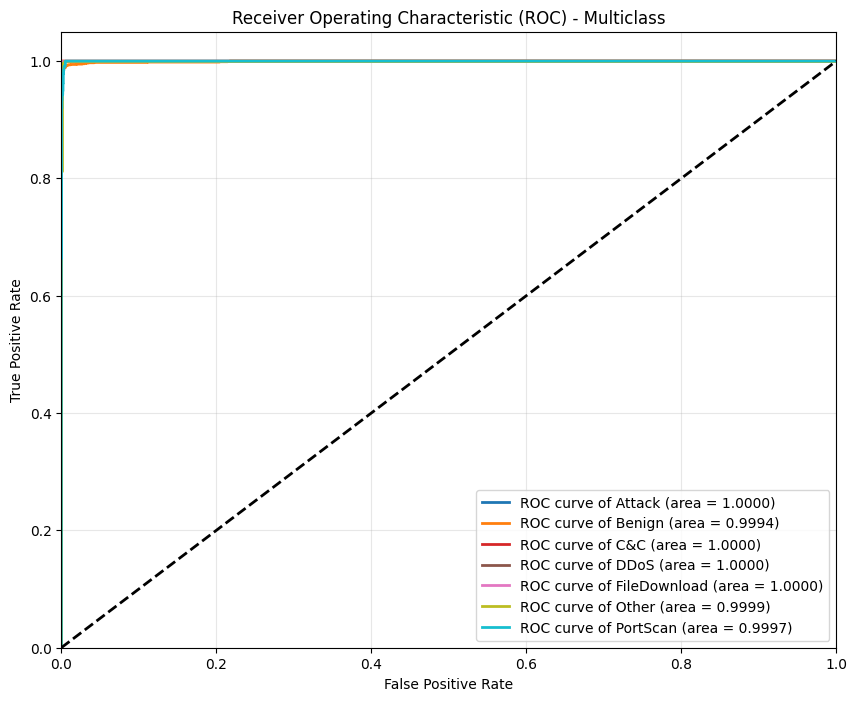

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize the test labels for multiclass ROC calculation
y_test_bin = label_binarize(y_test_m, classes=range(len(le_multi.classes_)))
n_classes = y_test_bin.shape[1]

# Get predicted probabilities for each class
y_score = lgbm_weighted.predict_proba(X_test_m)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
# Updated: Using matplotlib.colormaps to avoid deprecation warning
colors = plt.get_cmap('tab10')(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {le_multi.classes_[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Analyzing Port Feature Influence
We observed that `id.orig_p` and `id.resp_p` have the highest 'Gain' and 'Split' importance. The following plot shows the distribution of the destination port (`id.resp_p`) for each class to visualize why the model relies on it so heavily.

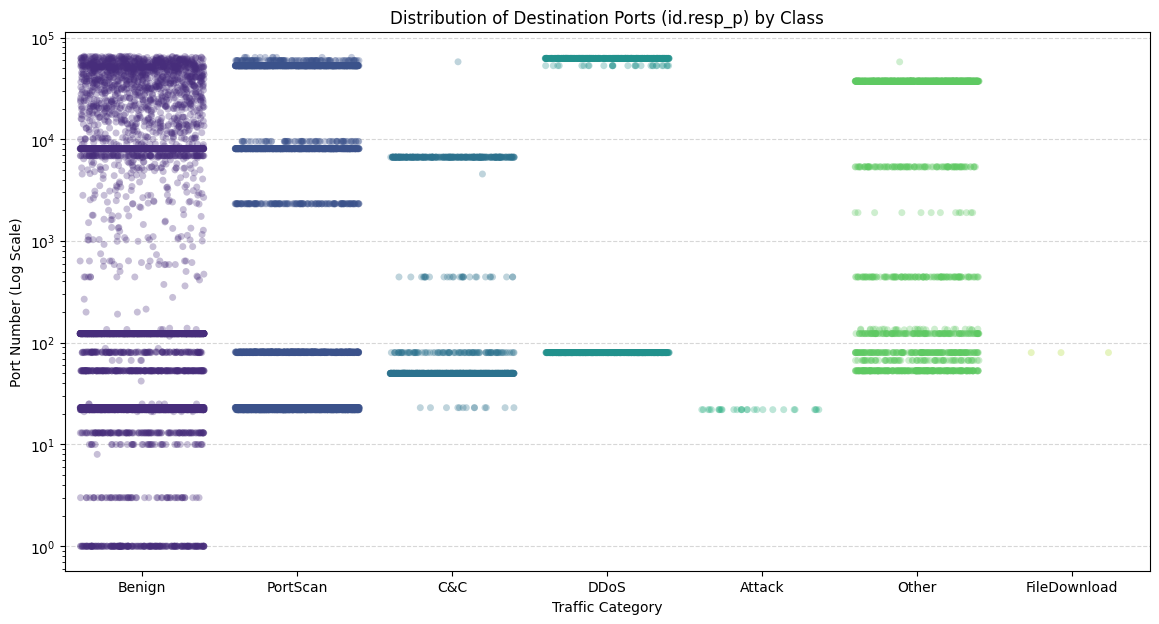

Top Destination Port per Class:
- Attack: 22
- Benign: 123
- C&C: 50
- DDoS: 80
- FileDownload: 80
- Other: 37215
- PortScan: 23


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to common ports or a subset for better visualization
plt.figure(figsize=(14, 7))
sns.stripplot(data=df_multi, x='target_class', y='id.resp_p', jitter=0.4, alpha=0.3, palette='viridis', hue='target_class', legend=False)

plt.yscale('log') # Use log scale because port numbers range from 0 to 65535
plt.title('Distribution of Destination Ports (id.resp_p) by Class')
plt.ylabel('Port Number (Log Scale)')
plt.xlabel('Traffic Category')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Print the most frequent destination port for each class
print("Top Destination Port per Class:")
for cls in le_multi.classes_:
    top_port = df_multi[df_multi['target_class'] == cls]['id.resp_p'].mode().values
    port_val = top_port[0] if len(top_port) > 0 else "N/A"
    print(f"- {cls}: {port_val}")

Corrected SHAP matrix shape for 'Attack': (500, 10)


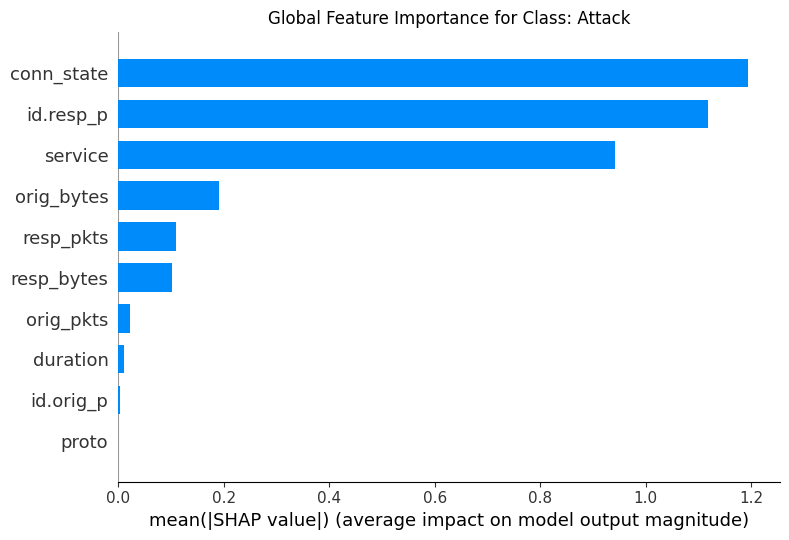

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialize explainer
explainer = shap.TreeExplainer(lgbm_weighted)

# 2. Select a subset for explanation
subset_size = 500
X_subset = X_test_m.iloc[:subset_size]

# 3. Calculate SHAP values
# Multiclass SHAP output can be a list of arrays or a 3D array (samples, features, classes)
shap_results = explainer.shap_values(X_subset)

# 4. Identify the 'Attack' class index
attack_idx = list(le_multi.classes_).index('Attack')

# 5. Extract values for the Attack class and ensure correct shape (samples, features)
if isinstance(shap_results, list):
    shap_values_attack = shap_results[attack_idx]
else:
    shap_values_attack = shap_results[:, :, attack_idx]

print(f"Corrected SHAP matrix shape for 'Attack': {shap_values_attack.shape}")

# 6. Global summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_attack, X_subset, plot_type='bar', show=False)
plt.title('Global Feature Importance for Class: Attack')
plt.tight_layout()
plt.show()

Generating local explanation for Attack instance at subset index 449


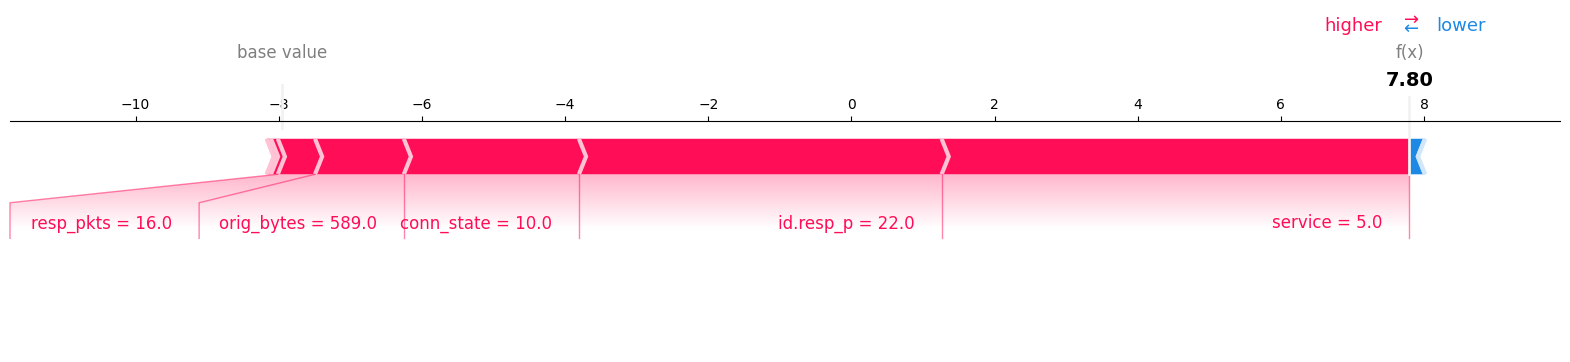

In [ ]:
# Identify indices of 'Attack' instances within the same subset
y_subset = y_test_m[:subset_size]
actual_attack_indices = np.where(y_subset == attack_idx)[0]

if len(actual_attack_indices) > 0:
    # Select the first 'Attack' instance found
    local_idx = actual_attack_indices[0]
    print(f"Generating local explanation for Attack instance at subset index {local_idx}")

    # Handle expected value for multiclass
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_value = explainer.expected_value[attack_idx]
    else:
        base_value = explainer.expected_value

    # Display the force plot
    shap.initjs()
    shap.force_plot(
        base_value,
        shap_values_attack[local_idx, :],
        X_subset.iloc[local_idx, :],
        matplotlib=True
    )
else:
    print('No instances of Attack were found in the subset to visualize.')

### SHAP Dependency Plots for 'Attack' Class
Dependency plots show the effect of a single feature across the whole dataset. They plot the SHAP value of that feature against its actual value for every instance. We will focus on the top 3 features identified globally: `conn_state`, `id.resp_p`, and `service`.

<Figure size 1000x600 with 0 Axes>

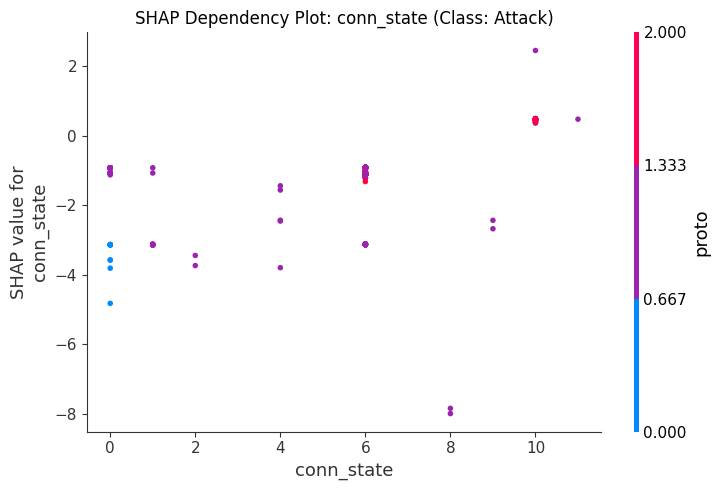

<Figure size 1000x600 with 0 Axes>

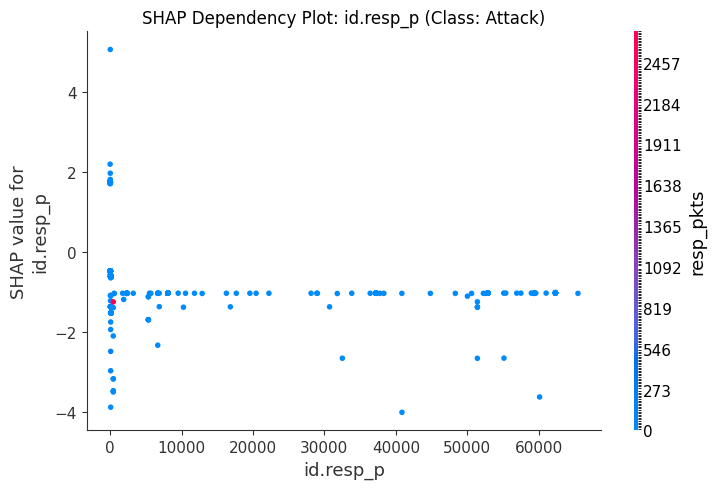

<Figure size 1000x600 with 0 Axes>

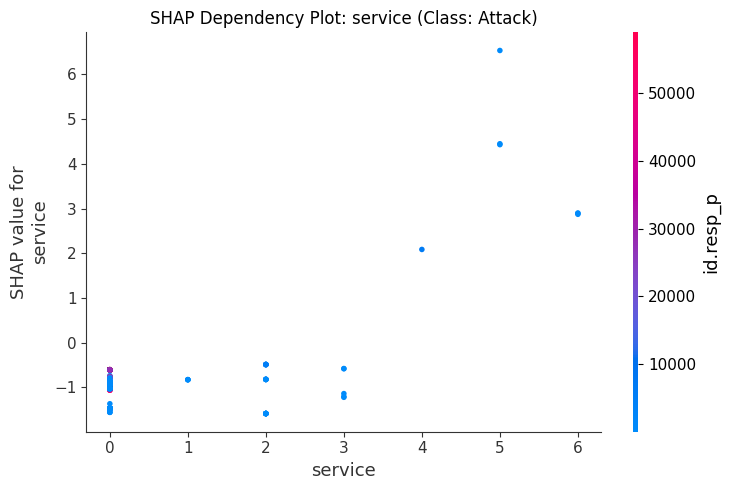

In [ ]:
import shap
import matplotlib.pyplot as plt

# Features to plot
top_features = ['conn_state', 'id.resp_p', 'service']

# Generate dependency plots
for feature in top_features:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        feature,
        shap_values_attack,
        X_subset,
        display_features=X_subset,
        interaction_index='auto',
        show=False
    )
    plt.title(f'SHAP Dependency Plot: {feature} (Class: Attack)')
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

# Create a DataFrame from the SHAP values for the 'Attack' class
# Use the column names from X_subset for clarity
shap_attack_df = pd.DataFrame(shap_values_attack, columns=X_subset.columns)

# Define the output path
csv_output_path = '/content/shap_values_attack.csv'

# Save to CSV
shap_attack_df.to_csv(csv_output_path, index=False)

print(f"Successfully saved SHAP values for the 'Attack' class to: {csv_output_path}")
display(shap_attack_df.head())

Successfully saved SHAP values for the 'Attack' class to: /content/shap_values_attack.csv


,id.orig_p,id.resp_p,proto,service,duration,orig_bytes,resp_bytes,conn_state,orig_pkts,resp_pkts
0,0.000641,-0.616776,-0.000574,-0.864350,-0.002296,-0.133922,0.082987,-1.079610,0.019141,-0.070317
1,-0.000871,-0.484234,-0.000420,-0.936216,-0.005602,-0.136006,0.083867,-1.142533,0.017807,-0.076469
2,-0.000858,-1.036233,-0.000487,-0.606891,-0.002272,-0.134744,0.083730,-0.922352,0.019014,-0.070436
3,0.004585,-3.482592,-0.000349,2.893659,-0.125049,0.484216,-0.193674,-2.440237,-0.017609,0.204001
4,-0.007645,-1.038666,-0.000422,-0.607383,0.000154,-0.135223,0.083440,-0.920767,0.018052,-0.075775


<Figure size 1200x800 with 0 Axes>

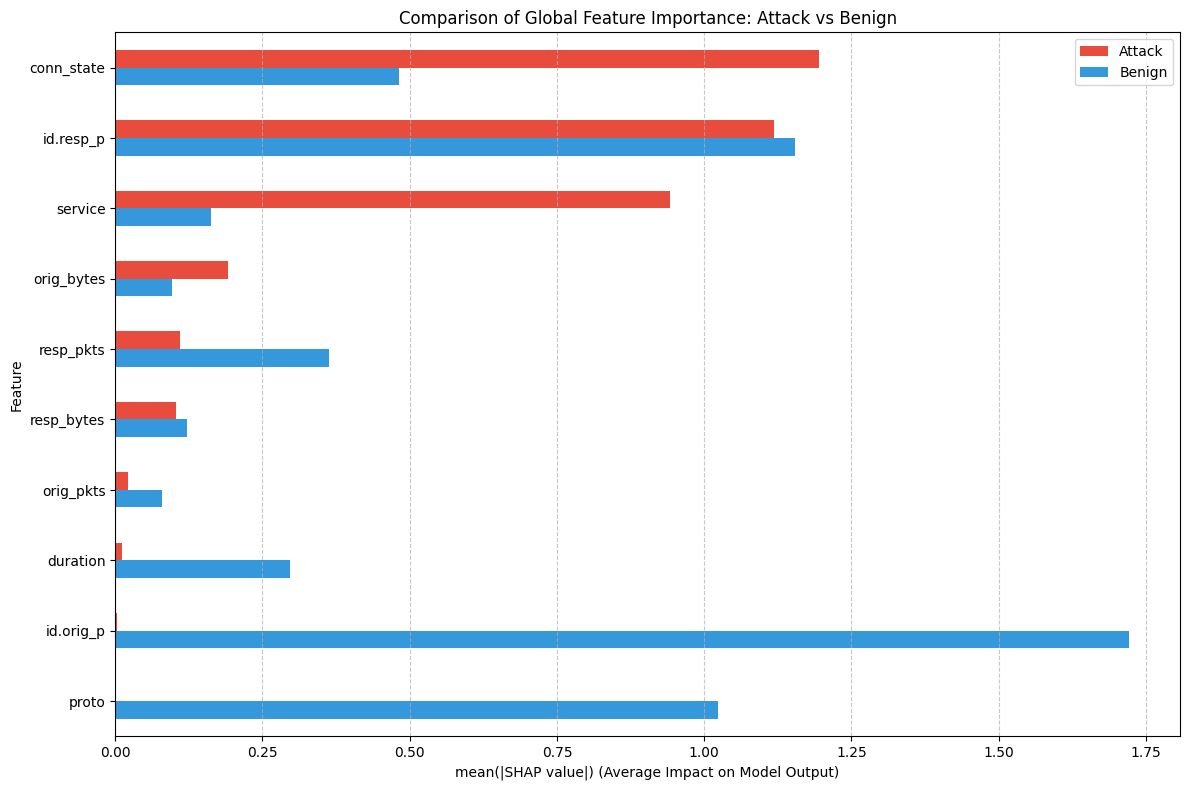

Top drivers for Benign traffic:


,Feature,Benign
0,id.orig_p,1.721620
1,id.resp_p,1.154740
2,proto,1.022653
7,conn_state,0.482647
9,resp_pkts,0.362329


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import shap

# 1. Identify the 'Benign' class index
benign_idx = list(le_multi.classes_).index('Benign')

# 2. Extract SHAP values for the Benign class
if isinstance(shap_results, list):
    shap_values_benign = shap_results[benign_idx]
else:
    shap_values_benign = shap_results[:, :, benign_idx]

# 3. Calculate mean absolute SHAP values for comparison
# This represents the average impact of each feature on the model output magnitude
mean_shap_attack = np.abs(shap_values_attack).mean(axis=0)
mean_shap_benign = np.abs(shap_values_benign).mean(axis=0)

# 4. Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature': X_subset.columns,
    'Attack': mean_shap_attack,
    'Benign': mean_shap_benign
}).sort_values(by='Attack', ascending=False)

# 5. Plotting the comparison
plt.figure(figsize=(12, 8))
comparison_df.set_index('Feature').plot(kind='barh', figsize=(12, 8), color=['#e74c3c', '#3498db'])
plt.title('Comparison of Global Feature Importance: Attack vs Benign')
plt.xlabel('mean(|SHAP value|) (Average Impact on Model Output)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top drivers for Benign traffic:")
display(comparison_df[['Feature', 'Benign']].sort_values(by='Benign', ascending=False).head(5))

To compare the drivers for 'Attack' versus 'Benign' traffic, I'll calculate the SHAP values for the 'Benign' class and then visualize the global feature importance for both classes together. This will highlight which features the model uses to distinguish between malicious and normal behavior.

The comparative analysis of feature importance between Attack and Benign traffic is complete.

Key Findings:
Attack Class Drivers: The model distinguishes malicious traffic primarily through the conn_state (connection state), id.resp_p (destination port), and service (application-level service).

This suggests specific network behaviors and targeted ports are strong indicators of an attack.

Benign Class Drivers: For normal traffic, the model relies heavily on id.orig_p (source port), id.resp_p (destination port), and proto (protocol).

The high importance of the source port in Benign traffic often reflects the typical ephemeral port behavior of standard client-side applications.

Comparison Summary:
Rank	Top Attack Drivers	Top Benign Drivers
1	conn_state (1.19)	id.orig_p (1.72)
2	id.resp_p (1.11)	id.resp_p (1.15)
3	service (0.94)	proto (1.02)

The chart shows that while destination ports are critical for identifying both types of traffic, the connection state is a much more significant driver for detecting attacks than it is for identifying benign traffic. Conversely, the source port and protocol type are the primary keys the model uses to verify normal traffic patterns.



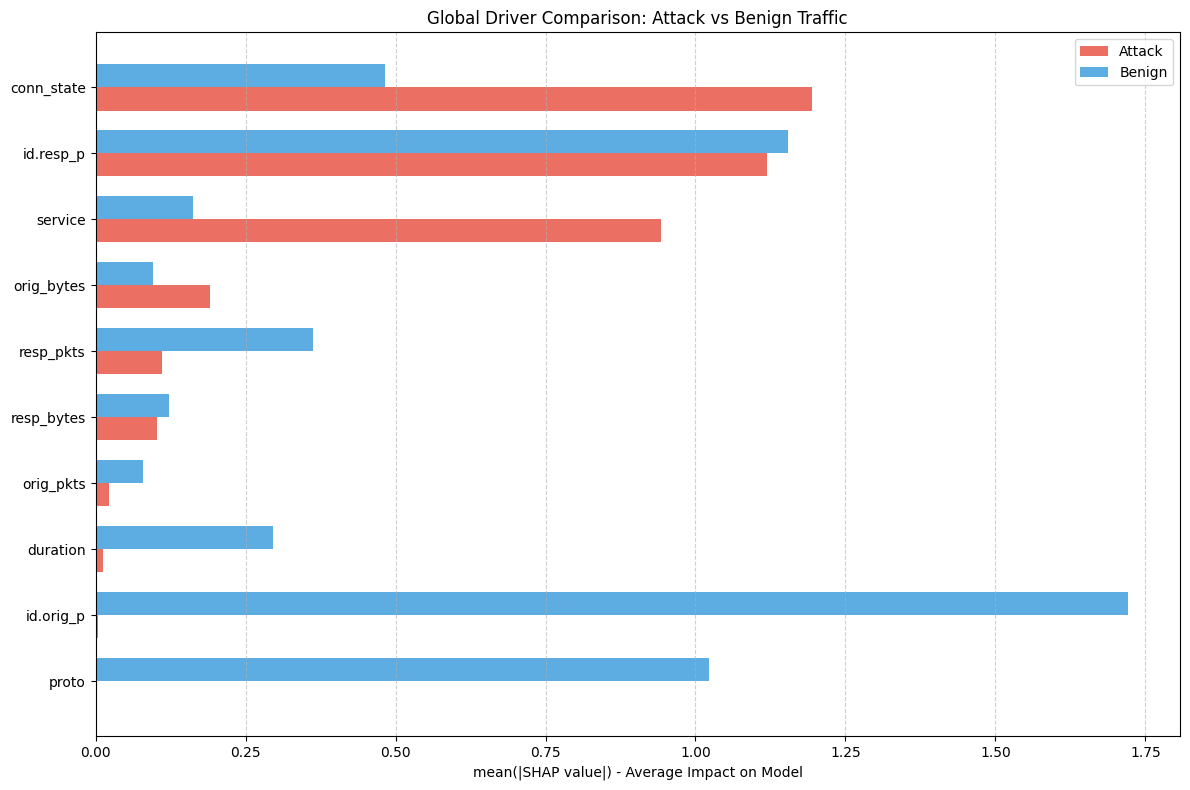

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by 'Attack' importance for consistent visualization
plot_df = comparison_df.sort_values(by='Attack', ascending=True)

# Create the side-by-side bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Set positions for the bars
features = plot_df['Feature']
y_pos = range(len(features))
width = 0.35

# Plot bars
ax.barh([p - width/2 for p in y_pos], plot_df['Attack'], width, label='Attack', color='#e74c3c', alpha=0.8)
ax.barh([p + width/2 for p in y_pos], plot_df['Benign'], width, label='Benign', color='#3498db', alpha=0.8)

# Styling
ax.set_yticks(y_pos)
ax.set_yticklabels(features)
ax.set_xlabel('mean(|SHAP value|) - Average Impact on Model')
ax.set_title('Global Driver Comparison: Attack vs Benign Traffic')
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()